# HW4

## Logistic Regression

In [50]:
from NumberGenerator import *
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [51]:
n = 50
mx1 = my1 = 1
mx2 = my2 = 3
vx1 = vy1 = 2
vx2 = vy2 = 4
N = 2 * n

In [52]:
def PrintResult(w, d1, d2, ax, title):
    print("\nw:")
    print(w[0])
    print(w[1])
    print(w[2])

    i1p1 = 0
    i1p2 = 0
    i2p1 = 0
    i2p2 = 0
    p1_x = []
    p1_y = []
    p2_x = []
    p2_y = []

    for data in d1:
        z = w[0] + w[1] * data[0] + w[2] * data[1]
        if 1 / (1 + np.exp(-z)) < 0.5:
            i1p1 += 1
            p1_x.append(data[0])
            p1_y.append(data[1])
        else:
            i1p2 += 1
            p2_x.append(data[0])
            p2_y.append(data[1])

    for data in d2:
        z = w[0] + w[1] * data[0] + w[2] * data[1]
        if 1 / (1 + np.exp(-z)) < 0.5:
            i2p1 += 1
            p1_x.append(data[0])
            p1_y.append(data[1])
        else:
            i2p2 += 1
            p2_x.append(data[0])
            p2_y.append(data[1])
    
    print("\nConfusion Matrix:\n")
    print("                      Predict cluster 1       Predict cluster 2")
    print(f"Is cluster 1                 {i1p1:02d}                      {i1p2:02d}         ")
    print(f"Is cluster 2                 {i2p1:02d}                      {i2p2:02d}         ")
    print()
    print(f"Sensitivity (Successfully predict cluster 1): {i1p1 / n}")
    print(f"Specificity (Successfully predict cluster 2): {i2p2 / n}")
    print("===================================================================================")

    ax.scatter(p1_x, p1_y, color='red')
    ax.scatter(p2_x, p2_y, color='blue')
    ax.set_title(title)

In [61]:
def GradientDescent(phi, y):
    w_old = np.ones((3, 1))
    w_new = np.ones((3, 1))
    learning_rate = 0.1
    threshold = 1e-5
    count = 0

    while count < 10000:
        count += 1
        z = phi.T.dot(w_old)
        y_est = 1 / (1 + np.exp(-z))
        gradient = (1 / N) * phi.dot(y_est - y)
        w_new = w_old - learning_rate * gradient
        
        if np.linalg.norm(w_new - w_old) < threshold:
            break
        w_old = w_new

    return w_new

In [ ]:
def NewtonsMethod(phi, y):
    w_old = np.ones((3, 1))
    w_new = np.ones((3, 1))
    learning_rate = 0.1
    threshold = 1e-5
    ones = np.ones((N, 1))
    count = 0

    while count < 10000:
        count += 1
        z = phi.T.dot(w_old)
        y_est = 1 / (1 + np.exp(-z))
        gradient = (1 / N) * phi.dot(y_est - y)
        hessian = (1 / N) * y_est.T.dot(ones - y_est) * phi.dot(phi.T)
        
        if np.linalg.det(hessian) == 0:
            w_new = w_old - learning_rate * gradient
        else:
            w_new = w_old - np.linalg.inv(hessian).dot(gradient)

        if np.linalg.norm(w_new - w_old) < threshold:
            break
        
        w_old = w_new

    return w_new

2367
Gradient descent:

w:
[-2.80369359]
[0.79754574]
[0.63850652]

Confusion Matrix:

                      Predict cluster 1       Predict cluster 2
Is cluster 1                 41                      09         
Is cluster 2                 10                      40         

Sensitivity (Successfully predict cluster 1): 0.82
Specificity (Successfully predict cluster 2): 0.8
1918
Newton`s method:

w:
[-2.80974984]
[0.79921307]
[0.63972717]

Confusion Matrix:

                      Predict cluster 1       Predict cluster 2
Is cluster 1                 41                      09         
Is cluster 2                 10                      40         

Sensitivity (Successfully predict cluster 1): 0.82
Specificity (Successfully predict cluster 2): 0.8


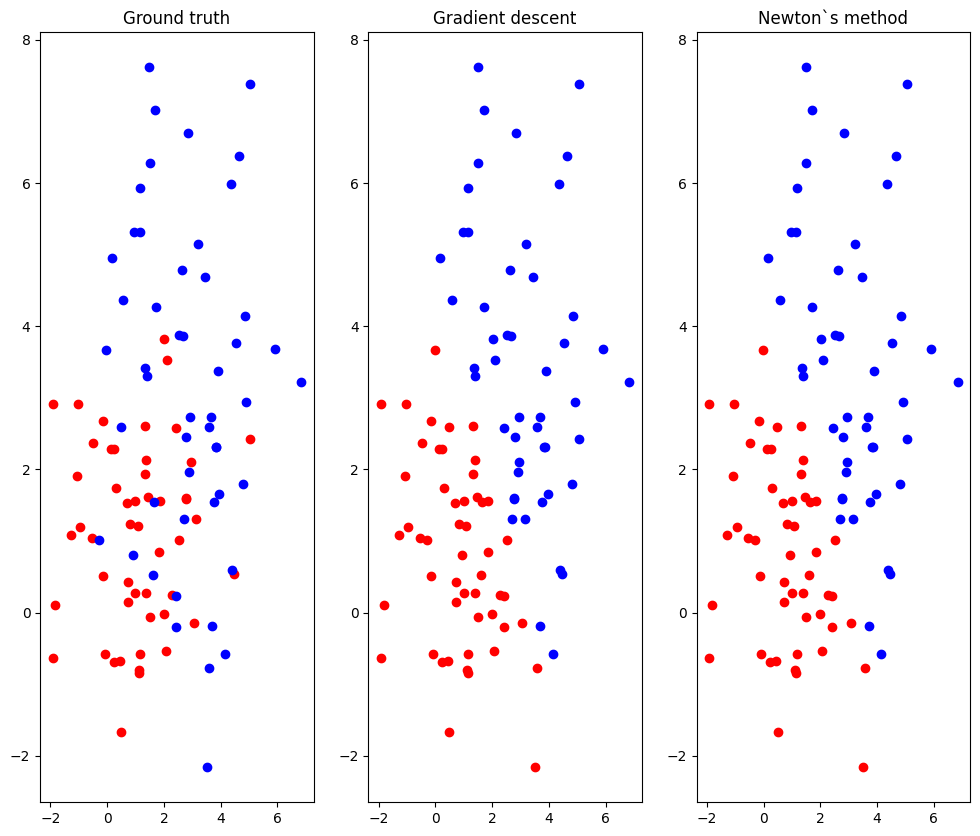

In [60]:
d1 = []
d2 = []

for i in range(n):
    d1.append([Normal(mx1, vx1), Normal(my1, vy1)])
    d2.append([Normal(mx2, vx2), Normal(my2, vy2)])

d1 = np.array(d1)
d2 = np.array(d2)
D = np.vstack((d1, d2))
phi = np.vstack((np.ones((1, N)), D.T))
y = np.vstack((np.zeros((n, 1)), np.ones((n, 1)))) # labels, 0 for D1 & 1 for D2

fig, axs = plt.subplots(1, 3, figsize=(12, 10))
axs[0].scatter(d1.T[0], d1.T[1], color='red')
axs[0].scatter(d2.T[0], d2.T[1], color='blue')
axs[0].set_title("Ground truth")

w1 = GradientDescent(phi, y)
print("Gradient descent:")
PrintResult(w1, d1, d2, axs[1], "Gradient descent")

w2 = NewtonsMethod(phi, y)
print("Newton`s method:")
PrintResult(w2, d1, d2, axs[2], "Newton`s method")

plt.show()

## EM Algorithm

In [74]:
import numpy as np
import struct
from scipy.special import logsumexp
from tqdm import tqdm, trange
from collections import Counter

In [63]:
train_images_filepath = "train-images.idx3-ubyte_"
train_labels_filepath = "train-labels.idx1-ubyte_"

In [64]:
def LoadImages(filepath):
    with open(filepath,'rb') as f:
        magic, size = struct.unpack(">II", f.read(8))
        nrows, ncols = struct.unpack(">II", f.read(8))
        data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
        data = data.reshape((size, nrows, ncols))

    return data, size, nrows, ncols

def LoadLabels(filepath):
    with open(filepath,'rb') as f:
        magic, size = struct.unpack(">II", f.read(8))
        data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
        # data = data.reshape((size,))

    return data

images, N, n_row, n_col = LoadImages(train_images_filepath)
labels = LoadLabels(train_labels_filepath)

X = images.reshape(N, -1)
X = X // 128
n_pixel = n_row * n_col
n_class = 10

In [78]:
def PrintImages(p, finished, cluster_to_label=[]):
    for k in range(n_class):
        print(f"class {k}:")
        for i in range(n_pixel):
            if p[i][k] > 0.5:
                print("1 ", end='')
            else:
                print("0 ", end='')
            
            if (i + 1) % n_col == 0:
                print()

        print()

In [80]:
lambda_old = np.array([0.2 for i in range(n_class)])
lambda_new = np.array([0.2 for i in range(n_class)])
p_old = np.random.rand(n_pixel, n_class) * 0.2 + 0.4
p_new = np.ones((n_pixel, n_class))
w = np.zeros((N, n_class))
threshold = 1e-2
count = 0
prev_sum_log_likelihood = -np.inf

while count < 100:
    count += 1
    # E Step
    log_p = np.log(p_old + 1e-10)
    log_q = np.log(1 - p_old + 1e-10)
    log_likelihood = X @ log_p + (1 - X) @ log_q + np.log(lambda_old + 1e-10)
    log_w = log_likelihood - logsumexp(log_likelihood, axis=1, keepdims=True)
    w = np.exp(log_w)

    sum_log_likelihood = np.sum(log_likelihood)
    difference = abs(sum_log_likelihood - prev_sum_log_likelihood) / N # 判斷收斂

    # M Step
    lambda_new = np.mean(w, axis=0)
    p_new = (X.T @ w) / np.sum(w, axis=0, keepdims=True)

    PrintImages(p_new, False)
    print(f"No. of Iteration: {count}, Difference: {difference}")
    print("\n--------------------------------------------------------------------\n")

    if difference < threshold:
        break

    lambda_old = np.copy(lambda_new)
    p_old = np.copy(p_new)
    prev_sum_log_likelihood = sum_log_likelihood

class 0:
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 

In [ ]:
cluster_pred = np.argmax(w, axis=1)
cluster_to_label = {} # 對照表

for k in range(n_class):
    true_labels_in_k = labels[cluster_pred == k] # cluster k 的真實 label 都是哪些數字
    most_common = Counter(true_labels_in_k).most_common(1)[0][0] # 找出裡面最多的那個數字 label 
    cluster_to_label[k] = most_common



In [ ]:
n_class = 10
lambda_old = np.array([0.2 for i in range(n_class)])
lambda_new = np.array([0.2 for i in range(n_class)])
p_old = np.ones((n_pixel, n_class))
p_old = p_old / 2
p_new = np.ones((n_pixel, n_class))
w = np.zeros((N, n_class))
threshold = 1e-2
max_count = 100

for count in trange(max_count):
    # E Step
    for t in trange(N):
        for k in range(n_class):
            numerator = 0     # 分子
            denominator = 0   # 分母

            for k1 in range(n_class):
                log_prob = np.log(lambda_old[k1])  # 避免 underflow 所以用 log domain
                

                for i in range(n_row):
                    for j in range(n_col):
                        p = p_old[pixel][k1]
                        x = X[t][pixel]
                        log_prob += x * np.log(p + 1e-10) + (1 - x) * np.log(1 - p + 1e-10)

                denominator += np.exp(log_prob)

                if k1 == k:
                    numerator = np.exp(log_prob)

            w[t][k] = numerator / denominator



    # M Step
    w_sum = [0 for i in range(n_class)]
    for k in range(n_class):
        for t in range(N):
            w_sum[k] += w[t][k]

        lambda_new[k] = w_sum[k] / N
    
    for i in trange(n_row):
        for j in range(n_col):
            for k in range(n_class):
                sum = 0

                for t in range(N):
                    sum += w[t][k] * images[t][i][j]

                p_new[i][j][k] = sum / w_sum[k]

    if np.linalg.norm(lambda_new - lambda_old) < threshold:
        break

    lambda_old = lambda_new
    p_old = np.copy(p_new)

print(lambda_new)